In [ ]:
#Building the linear regression from scratch without Libraries
import numpy as np
import pandas as pd
import seaborn  as sns

**Linear Regression**

In [ ]:
class Linear_Regression():
  def __init__(self, learning_rate, num_of_iterations):
    self.learning_rate = learning_rate
    self.num_iterations = num_of_iterations

  def fit(self,X,Y):

    #These x and y are salary and experience

    self.m,self.n=X.shape #m,n are the rows and columns

    #intialing weight and bias

    self.w=np.zeros(self.n)
    self.b=0
    self.X=X
    self.Y=Y

    #implementing gradient and descent
    for i in range(self.num_iterations):
      self.update_weights()

  def update_weights(self):

    Y_prediction=self.predict(self.X)

    #calculating gradients

    dw=-(2*(self.X.T).dot(self.Y - Y_prediction))/self.m
    db=-2*np.sum(self.Y - Y_prediction)/self.m

    #updating the weights

    self.w = self.w - self.learning_rate*dw
    self.b = self.b - self.learning_rate*db

  def predict(self,X):

    return X.dot(self.w)+self.b

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
data=pd.read_csv('/content/salary_data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
data.shape

(30, 2)

In [ ]:
data.isnull().sum()

,0
YearsExperience,0
Salary,0


In [ ]:

X=data.iloc[:,:-1].values
Y=data.iloc[:,1].values

In [ ]:
print(X)
print(Y)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]
[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=2)

In [ ]:
model=Linear_Regression(learning_rate=0.02,num_of_iterations=1000)

In [ ]:
model.fit(X_train,Y_train)

In [ ]:
#printing or Analyzing the values of weigth and bias
print("Weight =",model.w[0])
print("Bias=",model.b)

Weight = 9514.400999035135
Bias= 23697.406507136307


This means the predicted salary could be y=9514(experience)+23697

In [ ]:
test_data_prediction=model.predict(X_test)
print(test_data_prediction)

[ 36066.12780588  34163.24760607  66512.21100279  58900.69020357
  91249.65360029  80783.81250135 101715.49469922  52240.60950424
  42726.20850521  88395.33330058]


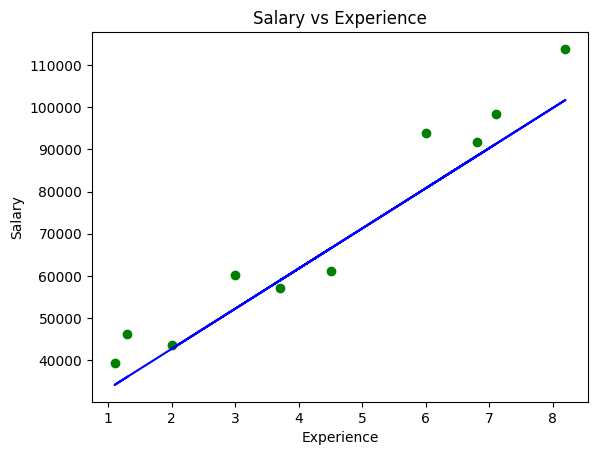

In [ ]:
#Lets visualize the predicted vs actual values
plt.scatter(X_test,Y_test,color='g')
plt.plot(X_test,test_data_prediction,color='b')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()